# 3.20_NonPointed--VIS_and_NIR_Flatfield

## Load In

In [1]:
''' Make sure you have pandorasim installed and updated '''
# pandorasim, Version: 1.0.10
# pandorasat, Version: 0.5.22

import pandorasat as ps
import pandorasim as pp
ps.utils.get_phoenix_model(teff=7000, jmag=10) ### this is a temporary fix to an import error with pandorasim
from pandorasim import VisibleSim, NIRSim
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord, Longitude
from astropy.io import fits
from pandorasat.plotting import animate
from pandorasat.plotting import save_mp4, save_gif
from astropy.time import Time, TimeDelta

### Importing additional functions and constants used in this notebook
import sys, os
sys.path.append(os.path.abspath('..'))
from CommissFunctions import generate_task_plan 
from CommissFunctions import data_rate, bits_per_pix_VIS, compression_fractor_VIS, frame_time_VIS, stored_frames_per_int_VIS, pass_time_min, regions_NIR, bits_per_pix_NIR, compression_fractor_NIR, NIR_ra_shape, NIR_dec_shape


/Users/lindseywiser/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Define Array Location Function

In [2]:
''' Function defining the target location on the array -- this may be needed to illuminate different regions'''
### This function returns a location to point the telescope [in degrees] given an observation id number.
# We will update this function to adjust the pattern based on input from the stakeholders.
# We currently assume that the "home" location is with our target in the center of the NIR array. 
# (ra, dec)=(10,10)deg is only a default for visualization in the next cell.
###

### Set the number of observations here
num_observations = 3 

def array_location(obsid_num, ra_home=10*u.degree, dec_home=10*u.degree):
    
    ra_home = ra_home
    dec_home = dec_home
    NIR_shape_deg = NIR_ra_shape.to(u.degree) ### Shape of the array in degrees. RA and Dec are the same.
    
    ### center 
    if obsid_num == 0 or obsid_num == 5: location = (ra_home, dec_home)
    
    offset = NIR_shape_deg *0.2  ### 20% movement
    if obsid_num == 1: location = (ra_home-offset, dec_home+offset)
    if obsid_num == 2: location = (ra_home+offset, dec_home-offset)
    
    new_ra = location[0]
    new_dec = location[1]
    return (new_ra, new_dec)

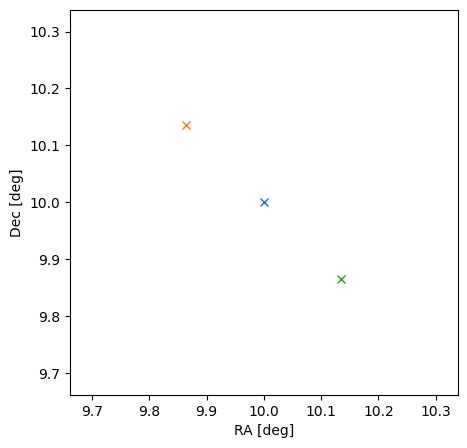

In [3]:
''' Plot the array location pattern on the VISDA array '''
### This is for visualizing the pattern, only. (10,10)deg is a default central location. See function above. 

plt.figure(figsize=(5, 5))
ax = plt.subplot()

for i in range(num_observations):
    loc = array_location(i) ### call the array_location() function above
    ax.plot(loc[0].value,loc[1].value, 'x')
    
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')

NIR_shape_deg = NIR_ra_shape.to(u.degree) ### set plot limits to the shape of VISDA
plt.xlim(10-(NIR_shape_deg.value/2), 10+(NIR_shape_deg.value/2))
plt.ylim(10-(NIR_shape_deg.value/2), 10+(NIR_shape_deg.value/2))

plt.show()

## Data Volume

3 observations, simultaneous VIS and NIR. VIS observations are full frame images. NIR observations have increasing subarray sizes. 

- This set up may be adjusted once the target is set.

In [4]:
''' Constants for this commissioning task '''
regions_VIS            = 1
VIS_xpix               = 2048
VIS_ypix               = 2048
frames_per_int_VIS     = 50
bits_per_int_VIS       = VIS_xpix * VIS_ypix * regions_VIS * bits_per_pix_VIS * stored_frames_per_int_VIS
int_and_reset_time_VIS = frame_time_VIS * frames_per_int_VIS
bits_per_sec_VIS       = bits_per_int_VIS / int_and_reset_time_VIS
bits_per_sec_comp_VIS  = bits_per_sec_VIS / compression_fractor_VIS

In [5]:
''' VIS Observations '''

##### VIS Observation 1 #####
num_int_VIS1            = 100
test_time_VIS1          = num_int_VIS1 * int_and_reset_time_VIS
bits_test_total_VIS1    = bits_per_sec_comp_VIS * test_time_VIS1
Gbits_test_packet_VIS1  = bits_test_total_VIS1 / 1E9 * 1.1 * 1.25
downlinks_VIS1          = Gbits_test_packet_VIS1 * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observation 1:', Gbits_test_packet_VIS1, 'Gbits')


##### VIS Observation 2 #####
num_int_VIS2            = 226
test_time_VIS2          = num_int_VIS2 * int_and_reset_time_VIS
bits_test_total_VIS2    = bits_per_sec_comp_VIS * test_time_VIS2
Gbits_test_packet_VIS2  = bits_test_total_VIS2 / 1E9 * 1.1 * 1.25
downlinks_VIS2          = Gbits_test_packet_VIS2 * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observation 2:', Gbits_test_packet_VIS2, 'Gbits')


##### VIS Observation 3 #####
num_int_VIS3            = 304
test_time_VIS3          = num_int_VIS3 * int_and_reset_time_VIS
bits_test_total_VIS3    = bits_per_sec_comp_VIS * test_time_VIS3
Gbits_test_packet_VIS3  = bits_test_total_VIS3 / 1E9 * 1.1 * 1.25
downlinks_VIS3          = Gbits_test_packet_VIS3 * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observation 3:', Gbits_test_packet_VIS3, 'Gbits')


VIS Observation 1: 6.151645866666668 Gbits
VIS Observation 2: 13.902719658666667 Gbits
VIS Observation 3: 18.701003434666667 Gbits


In [6]:
''' NIR Observations '''

#### NIR Observation 1 ####
NIR_xpix_NIR1              = 84
NIR_ypix_NIR1              = 400
stored_frames_per_int_NIR1 = 24
frames_per_int_NIR1        = 24 
num_int_NIR1               = 120
frame_time_NIR1            = NIR_xpix_NIR1 * NIR_ypix_NIR1 * 0.00001 #sec
int_and_reset_time_NIR1    = frame_time_NIR1 * (frames_per_int_NIR1+1)
bits_per_int_NIR1          = NIR_xpix_NIR1 * NIR_ypix_NIR1 * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR1
bits_per_sec_NIR1          = bits_per_int_NIR1 / int_and_reset_time_NIR1
test_time_NIR1             = num_int_NIR1 * int_and_reset_time_NIR1
bits_per_sec_comp_NIR1     = bits_per_sec_NIR1 / compression_fractor_NIR
bits_test_total_NIR1       = bits_per_sec_comp_NIR1 * test_time_NIR1
Gbits_test_packet_NIR1     = bits_test_total_NIR1 / 1E9 * 1.1 * 1.25
downlinks_NIR1             = Gbits_test_packet_NIR1 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observation 1:', Gbits_test_packet_NIR1, 'Gbits')


#### NIR Observation 2 ####
NIR_xpix_NIR2              = 516
NIR_ypix_NIR2              = 2084
stored_frames_per_int_NIR2 = 6
frames_per_int_NIR2        = 6 
num_int_NIR2               = 30
frame_time_NIR2            = NIR_xpix_NIR2 * NIR_ypix_NIR2 * 0.00001 #sec
int_and_reset_time_NIR2    = frame_time_NIR2 * (frames_per_int_NIR2+1)
bits_per_int_NIR2          = NIR_xpix_NIR2 * NIR_ypix_NIR2 * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR2
bits_per_sec_NIR2          = bits_per_int_NIR2 / int_and_reset_time_NIR2
test_time_NIR2             = num_int_NIR2 * int_and_reset_time_NIR2
bits_per_sec_comp_NIR2     = bits_per_sec_NIR2 / compression_fractor_NIR
bits_test_total_NIR2       = bits_per_sec_comp_NIR2 * test_time_NIR2
Gbits_test_packet_NIR2     = bits_test_total_NIR2 / 1E9 * 1.1 * 1.25
downlinks_NIR2             = Gbits_test_packet_NIR2 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observation 2:', Gbits_test_packet_NIR2, 'Gbits')


#### NIR Observation 3 ####
NIR_xpix_NIR3              = 2084
NIR_ypix_NIR3              = 2084
stored_frames_per_int_NIR3 = 6
frames_per_int_NIR3        = 6 
num_int_NIR3               = 10
frame_time_NIR3            = NIR_xpix_NIR3 * NIR_ypix_NIR3 * 0.00001 #sec
int_and_reset_time_NIR3    = frame_time_NIR3 * (frames_per_int_NIR3+1)
bits_per_int_NIR3          = NIR_xpix_NIR3 * NIR_ypix_NIR3 * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR3
bits_per_sec_NIR3          = bits_per_int_NIR3 / int_and_reset_time_NIR3
test_time_NIR3             = num_int_NIR3 * int_and_reset_time_NIR3
bits_per_sec_comp_NIR3     = bits_per_sec_NIR3 / compression_fractor_NIR
bits_test_total_NIR3       = bits_per_sec_comp_NIR3 * test_time_NIR3
Gbits_test_packet_NIR3     = bits_test_total_NIR3 / 1E9 * 1.1 * 1.25
downlinks_NIR3             = Gbits_test_packet_NIR3 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observation 3:', Gbits_test_packet_NIR3, 'Gbits')

NIR Observation 1: 1.0644480000000003 Gbits
NIR Observation 2: 2.12918112 Gbits
NIR Observation 3: 2.86641696 Gbits


### Total data volume

In [7]:
Gbits_total = (Gbits_test_packet_VIS1+Gbits_test_packet_NIR1) + (Gbits_test_packet_VIS2+Gbits_test_packet_NIR2) + (Gbits_test_packet_VIS3+Gbits_test_packet_NIR3)
downlinks_total = (downlinks_VIS1+downlinks_NIR1) + (downlinks_VIS2+downlinks_NIR2) + (downlinks_VIS3+downlinks_NIR3)
test_time_total = max([test_time_VIS1, test_time_NIR1]) + max([test_time_VIS2, test_time_NIR2]) + max([test_time_VIS3, test_time_NIR3])

print('Test time, total, no slew/overhead time:', test_time_total/60/60, 'hours')
print('Volume, total:', Gbits_total, 'Gbits')
print('Downlinks, total:', downlinks_total)

Test time, total, no slew/overhead time: 1.7522608888888889 hours
Volume, total: 44.815415040000005 Gbits
Downlinks, total: 18.6730896


In [8]:
### Adding important variables to a dictionary for later
obs_dict = {
    'VIS1': {'test_time': test_time_VIS1, 'num_int': num_int_VIS1},
    'VIS2': {'test_time': test_time_VIS2, 'num_int': num_int_VIS2},
    'VIS3': {'test_time': test_time_VIS3, 'num_int': num_int_VIS3},
    
    'NIR1': {'test_time': test_time_NIR1, 'xpix': NIR_xpix_NIR1, 'ypix': NIR_ypix_NIR1, 'frames_per_int': frames_per_int_NIR1, 'num_int': num_int_NIR1},
    'NIR2': {'test_time': test_time_NIR2, 'xpix': NIR_xpix_NIR2, 'ypix': NIR_ypix_NIR2, 'frames_per_int': frames_per_int_NIR2, 'num_int': num_int_NIR2},
    'NIR2': {'test_time': test_time_NIR3, 'xpix': NIR_xpix_NIR3, 'ypix': NIR_ypix_NIR3, 'frames_per_int': frames_per_int_NIR3, 'num_int': num_int_NIR3}
}

## The rest of this notebook should be run for each of the 10 observations. Select an observation number

In [9]:
observation_number = 0  ### possible numbers are 0, 1, 2

if observation_number == 0: 
    vis='VIS1'
    nir='NIR1'
elif observation_number == 1: 
    vis='VIS2'
    nir='NIR2'
elif observation_number == 2: 
    vis='VIS3'
    nir='NIR3'

## Define Target

In [10]:
### Posible Targets:
# ...
# ...
# ...
# ...

In [11]:
''' Finds target coordinates based on astropy '''
### You can do this differently as long as you have DEC and RA
target = "GJ 3470"
c = SkyCoord.from_name(target)


''' Identify the start time and end time of the observation '''
start_time = Time.now() # starting now. This should get overridden by the scheduler. 
test_time = max(obs_dict[vis]['test_time'], obs_dict[nir]['test_time'])
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta


''' Initialize a simulator object '''
### Set the number of ROIs and their sizes. 
### For now, NIRSim does not allow you to set the ROI_size. But we can still set it in the SOC file at the end.
simVIS = VisibleSim(ROI_size=(VIS_xpix, VIS_ypix), nROIs=regions_VIS) 
simNIR = NIRSim() # NIRSim(ROI_size=(obs_dict[nir]['xpix'], obs_dict[nir]['ypix']))

Output()

Output()

In [12]:
''' Define the center of our observation based on target location and observation number '''
location   = array_location(observation_number, c.ra, c.dec)
ra0        = location[0] 
dec0       = location[1] 
theta0     = 0*u.deg


''' Point the simulator to the corrected location '''
###        RA,   DEC,    Theta 
simVIS.point(ra0, dec0, theta0)
simNIR.point(ra0, dec0, theta0) ### this line has an known error. 

Output()

Output()

Output()

Output()

Output()

2025-02-19 21:40:29 WARNING: 0.0K source in catalog is not modelable. Setting to 2000K.

Output()

In [13]:
''' sim has various attributes you can print out '''
#print(sim.ra, sim.dec, sim.wcs)

''' Notably we have a Catalog of objects visable in the VIS FOV '''
cat = simVIS.source_catalog
#print(cat)

## Generate Observation

### VIS Observation

<Axes: title={'center': 'VISDA\n(RA:119.77 deg, Dec:15.39 deg, Roll:0.00 deg)'}, xlabel='Column [pixel]', ylabel='Row [pixel]'>

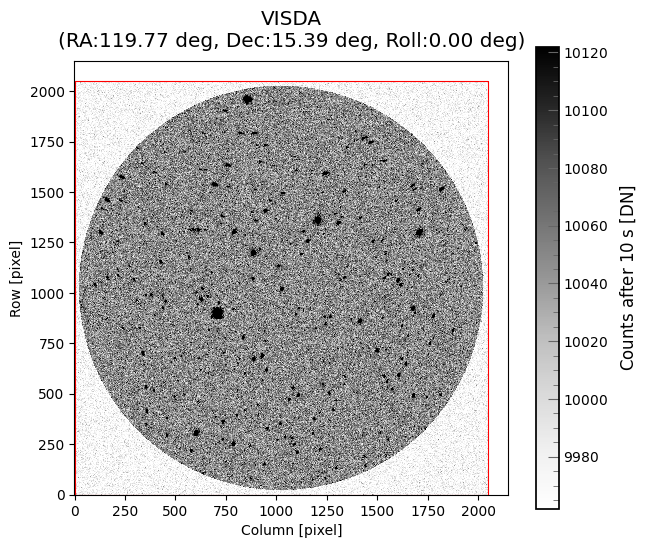

In [14]:
''' Plot the VIS Full Frame Image. ROIs are in red boxes defining the subarrays. '''
simVIS.show_FFI()

In [20]:
''' Create an Observation. '''
### This returns an astropy.io.fits.HDUList array. 
# `nreads` sets how many reads of the detector are coadded together to create a frame.
# `bin_frames` is a shortcut parameter to speed up computation. Must be a factor of nreads. We can ignore this for low nreads. 
# `nframes` sets how many frames will be returned.
# `start_time` indicates the time of observation. 
# `output_type` is set to array, for now. This make it easy to call, but we'll save it as a fits file later. 
###

### reduce the number of integrations to speed up calculations
reduction = 10 # set to 1 for no reduction
data = simVIS.observe(nreads=frames_per_int_VIS, bin_frames=1, nframes=int(obs_dict[vis]['num_int']/reduction), start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|█████████████████| 15/15 [00:56<00:00,  3.80s/it]


(1, 10, 2048, 2048)

### NIR Observation

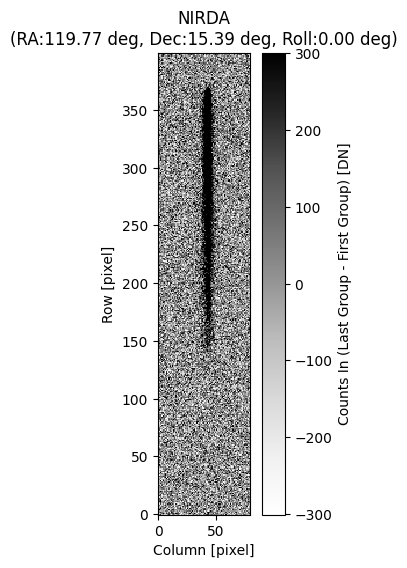

In [21]:
''' Plot the NIRDA subarray '''
simNIR.show_subarray();

In [22]:
''' Create a NIRDA observation. '''
### This returns an astropy.io.fits.HDUList array. The following parameters can be adjusted
# SC_Resets1 : Number of reset frames at the start of the first integration of exposure
# SC_Resets2 : Number of resent frames at the start of 1 through n integrations of exposure
# SC_DropFrames1 : Number of dropped frames after reset of any integration of exposure
# SC_DropFrames2 : Number of dropped frames in every group of integrations of exposure except the last group
# SC_DropFrames3 : Number of dropped frames in the last group of each integration of exposure
# SC_ReadFrames : Number of frames read during each group of integration of exposure
# SC_Groups : Number of groups per integration of exposure
# SC_Integrations : Number of integrations per exposure
# start_time : Time to start the observation. This is only used if returning a fits file, or supplying a flux function.
# noise : bool flag determining whether noise is simulated and included. Default is True.
# jitter : bool flag determining whether jitter is simulated and included. Default is True.
# output_type : String flag to determine the result output. Valid strings are "fits" or "array
###

ROIsize_override = (obs_dict[nir]['xpix'], obs_dict[nir]['ypix']) ### THIS CANNOT YET BE SPECIFIED IN sim.observe()

data = simNIR.observe(SC_ReadFrames=obs_dict[nir]['frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|█████████████████| 15/15 [04:44<00:00, 18.98s/it]


(120, 2, 400, 80)

## Save the Simulated Observation

In [ ]:
''' Re-Create the observations in the correct format for the .fits file (i.e., output_type set to default) '''
### Before, object_type was array for easy computation in this notebook, but that is not correct for the .fits file
hdulist_vis = simVIS.observe(nreads=obs_dict[vis]['frames_per_int'], bin_frames=1, nframes=obs_dict[vis]['num_int'], start_time=start_time)
hdulist_nir = simNIR.observe(SC_ReadFrames=obs_dict[nir]['frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], start_time=start_time)


''' Save our simulated observation in a fits file '''
targ = target.replace(" ", "")
VISrois_outfile = "3.20_VISrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
NIRrois_outfile = "3.20_NIRrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
hdulist_vis.writeto(VISrois_outfile, overwrite=True)
hdulist_nir.writeto(NIRrois_outfile, overwrite=True)

In [ ]:
### Show what is in our fits file: 
'''
Three FITS file extensions: 
    (1) PRIMARY: information about the simulated observation 
    (2) SCIENCE: data info, images
    (3) ROITABLE: VISDA pixel coordinates of the origin of the subarray, which is defined as the lower left corner
'''

hdul_rois = fits.open(VISrois_outfile) ### or NIRrois_outfile
print(hdul_rois.info())

#print('.')
#print('.')
#print('.')
#print('-- PRIMARY Headers --')
#print(hdul_rois[0].header)

#print('.')
#print('.')
#print('.')
#print('-- SCIENCE Headers --')
#print(hdul_rois[1].header)

#print('.')
#print('.')
#print('.')
#print('-- ROITABLE Headers --')
#print(hdul_rois[2].header)

## Data Products

### RD-A1: This data will be utilized to generate an in-flight VIS and NIR flat-field image

## Generate SOC File

In [26]:
'''Here we define the information required for scheduling the observation.'''
### Some variables may be removed/added/changed. Working on defining these with SOC meetings. 

variables = {
    'visit_id': '0320', ### setting based on task number. Could change. 
    'obs_id': f"{observation_number:03}", ### setting based on observation number. 
    'target': target, 
    'priority': 1, ### all commissioning is priority 1
    'start_time': start_time, 
    'stop_time': end_time, 
    'RA': ra0,
    'DEC': dec0, 
    
    'NIR_AvgGroups': 2, ### check what this is
    'NIR_ROI_StartX': ra0, 
    'NIR_ROI_StartY': dec0, 
    'NIR_ROI_SizeX': obs_dict[nir]['xpix'], 
    'NIR_ROI_SizeY': obs_dict[nir]['ypix'],
    'NIR_SC_Resets1': 1,
    'NIR_SC_Resets2': 1, 
    'NIR_SC_DropFrames1': 0,
    'NIR_SC_DropFrames2': 16,
    'NIR_SC_DropFrames3': 0, 
    'NIR_SC_ReadFrames': obs_dict[nir]['frames_per_int'],
    'NIR_targetID': target, 
    'NIR_SC_Groups': 2,
    'NIR_SC_Integrations': obs_dict[nir]['num_int'], 
    
    'VIS_StarRoiDetMethod': 0,  ### 0: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 1: Run star detection algorithm on first image and obtain star ROIs from results.
    'VIS_FramesPerCoadd': frames_per_int_VIS, 
    'VIS_NumTotalFramesRequested': obs_dict[vis]['num_int'], 
    'VIS_TargetRA': ra0, 
    'VIS_TargetDEC': dec0, 
    'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
    'VIS_StarRoiDimension': [VIS_xpix, VIS_ypix], 
    'VIS_MaxNumStarRois': '', ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
    'VIS_numPredefinedStarRois': regions_VIS, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
    'VIS_PredefinedStarRoiRa': '', ### currently defining as corner of ROI. We may update this to be ROI centers.
    'VIS_PredefinedStarRoiDec': '', 
    'VIS_targetID': target, 
    'VIS_NumExposuresMax': obs_dict[vis]['num_int'], 
    'VIS_ExposureTime_us': frame_time_VIS * 1000000  
}

In [27]:
'''Generate the SOC .xml file'''

output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_example_SOC.xml' 
generate_task_plan(variables, output_soc_file)